# 04 — Classical Innovation Modeling

## Purpose
This notebook fits classical innovation models to forecast residuals and evaluates their ability to reproduce residual distributions.

## Outputs
- Gaussian innovation models
- Bootstrap innovation models
- Student-t innovation models
- Innovation recovery diagnostics

## Future Work
- Add additional parametric innovation families
- Explore adaptive innovation selection

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

from src.api.innovations import (
    fit_innovations,
    sample_innovations,
)

set_seed(123)

config = ExperimentConfig()

dgp_names = config.dgp_names

forecast_models = [
    "VAR",
    "RNN",
]

innovation_model_names = [
    "gaussian",
    "bootstrap",
    "student_t",
]

n_paths = 1000
horizon = config.horizon
student_t_df = config.student_t_df

dirs = result_dirs(
    "04_innovations",
    test=False,
)

resid_dir = ROOT / "results" / "residuals" / "03_residuals"

residual_store = {}

for forecast_model in forecast_models:

    residual_store[forecast_model] = {}

    model_key = forecast_model.lower()

    for name in dgp_names:
        path = resid_dir / f"{name}_{model_key}_residuals.npz"
        data = load_array_npz(path)

        residuals = data["residuals"]

        residual_store[forecast_model][name] = residuals

        print(
            forecast_model,
            name,
            residuals.shape,
        )

VAR gaussian (599, 3)
VAR student_t (599, 3)
VAR mixture (599, 3)
VAR heteroskedastic (599, 3)
RNN gaussian (560, 3)
RNN student_t (560, 3)
RNN mixture (560, 3)
RNN heteroskedastic (560, 3)


## Fit Classical Innovation Models

Each innovation model is fitted to the VAR residuals from each DGP.

The Gaussian model estimates a residual mean and covariance matrix. The bootstrap model resamples empirical residual vectors. The Student-t model uses a heavy-tailed parametric approximation with fixed degrees of freedom.

In [2]:
from src.api.innovations import (
    fit_and_sample_classical_innovations,
)

innovation_models, sampled_innovations = fit_and_sample_classical_innovations(
    residual_store=residual_store,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
    n_paths=n_paths,
    horizon=horizon,
    seed=config.seed,
    output_dir=dirs["innovations"],
    student_t_df=student_t_df,
)

VAR gaussian gaussian (1000, 40, 3)
VAR gaussian bootstrap (1000, 40, 3)
VAR gaussian student_t (1000, 40, 3)
VAR student_t gaussian (1000, 40, 3)
VAR student_t bootstrap (1000, 40, 3)
VAR student_t student_t (1000, 40, 3)
VAR mixture gaussian (1000, 40, 3)
VAR mixture bootstrap (1000, 40, 3)
VAR mixture student_t (1000, 40, 3)
VAR heteroskedastic gaussian (1000, 40, 3)
VAR heteroskedastic bootstrap (1000, 40, 3)
VAR heteroskedastic student_t (1000, 40, 3)
RNN gaussian gaussian (1000, 40, 3)
RNN gaussian bootstrap (1000, 40, 3)
RNN gaussian student_t (1000, 40, 3)
RNN student_t gaussian (1000, 40, 3)
RNN student_t bootstrap (1000, 40, 3)
RNN student_t student_t (1000, 40, 3)
RNN mixture gaussian (1000, 40, 3)
RNN mixture bootstrap (1000, 40, 3)
RNN mixture student_t (1000, 40, 3)
RNN heteroskedastic gaussian (1000, 40, 3)
RNN heteroskedastic bootstrap (1000, 40, 3)
RNN heteroskedastic student_t (1000, 40, 3)


/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: divide by zero encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: overflow encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: invalid value encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: divide by zero encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: overflow encountered in matmul
  z = rng.multivariate_normal(
/

In [3]:
from src.api.innovations import innovation_diagnostics_table
innovation_diagnostics_df = innovation_diagnostics_table(
    residual_store=residual_store,
    sampled_innovations=sampled_innovations,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
)

save_table(
    innovation_diagnostics_df,
    dirs["tables"] / "innovation_diagnostics_by_series.csv",
)

innovation_diagnostics_df

,forecast_model,dgp,innovation_model,series,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,VAR,gaussian,empirical_residuals,1,1.422531e-16,1.010717,-0.075714,3.253305,0.253305,0.363965
1,VAR,gaussian,empirical_residuals,2,-4.170287e-17,0.996334,0.247366,3.271039,0.271039,0.020758
2,VAR,gaussian,empirical_residuals,3,-1.595830e-16,1.039456,0.004211,3.021352,0.021352,0.997564
3,VAR,gaussian,gaussian,1,-4.909467e-03,1.013502,0.007234,3.015161,0.015161,0.696184
4,VAR,gaussian,gaussian,2,2.966359e-03,0.991252,0.019194,3.047805,0.047805,0.044156
...,...,...,...,...,...,...,...,...,...,...
91,RNN,heteroskedastic,bootstrap,2,-1.256467e-02,1.774222,-0.187907,5.358408,2.358408,0.000000
92,RNN,heteroskedastic,bootstrap,3,3.327003e-02,1.873833,-0.261479,5.644302,2.644302,0.000000
93,RNN,heteroskedastic,student_t,1,-7.257121e-02,1.908548,-0.072655,6.764584,3.764584,0.000000
94,RNN,heteroskedastic,student_t,2,-2.543674e-02,1.792410,0.141196,9.785983,6.785983,0.000000


In [4]:
from src.api.innovations import innovation_diagnostics_summary

summary_df = innovation_diagnostics_summary(
    innovation_diagnostics_df,
)

save_table(
    summary_df,
    dirs["tables"] / "innovation_diagnostics_summary.csv",
)

summary_df

,forecast_model,dgp,innovation_model,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,RNN,gaussian,bootstrap,-1.626750e-02,0.940317,-0.026679,3.568832,0.568832,1.293063e-33
1,RNN,gaussian,empirical_residuals,-1.280691e-02,0.941256,-0.032683,3.588507,0.588507,1.069206e-01
2,RNN,gaussian,gaussian,-1.477469e-02,0.941048,0.009579,3.032459,0.032459,3.404168e-01
3,RNN,gaussian,student_t,-1.627411e-02,0.942214,-0.019602,7.133420,4.133420,0.000000e+00
4,RNN,heteroskedastic,bootstrap,-1.467131e-02,1.852732,-0.227999,5.604394,2.604394,0.000000e+00
5,RNN,heteroskedastic,empirical_residuals,-1.683607e-02,1.849100,-0.243038,5.702470,2.702470,3.501456e-32
6,RNN,heteroskedastic,gaussian,-2.051567e-02,1.848304,0.005602,3.009633,0.009633,4.040116e-01
7,RNN,heteroskedastic,student_t,-2.157884e-02,1.851771,0.018118,7.582880,4.582880,0.000000e+00
8,RNN,mixture,bootstrap,-6.665208e-03,1.423065,-0.077293,8.401543,5.401543,0.000000e+00
9,RNN,mixture,empirical_residuals,-9.765846e-04,1.427922,-0.091890,8.344716,5.344716,1.012133e-98


Saved: var_heteroskedastic_innovation_comparison.png


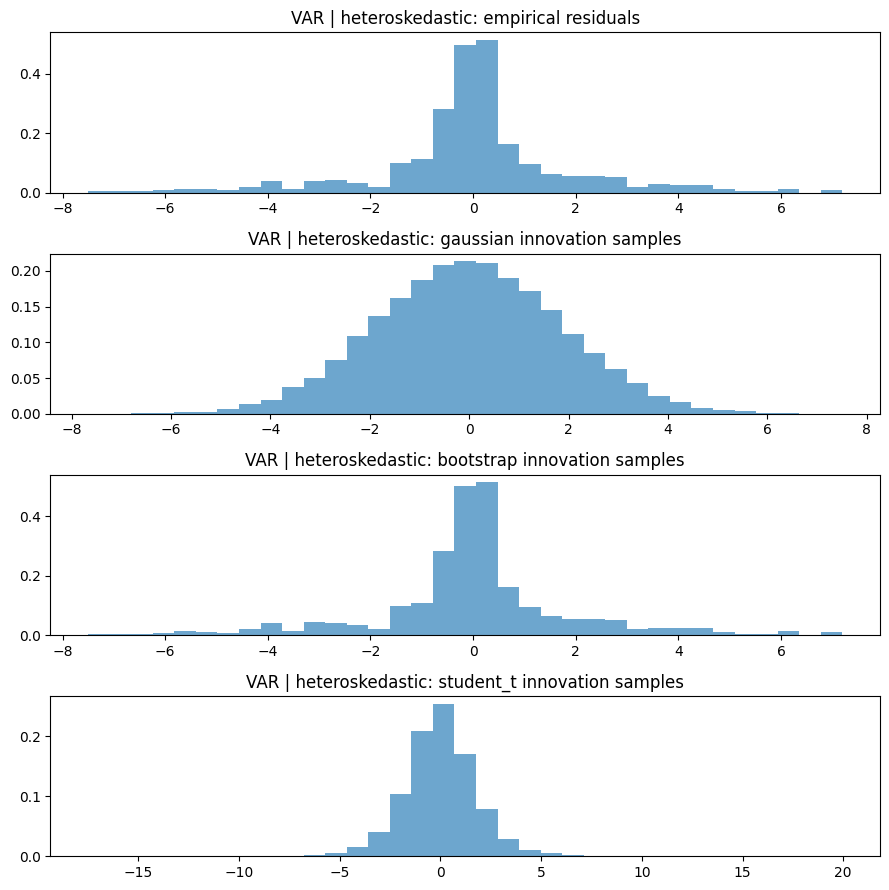

In [5]:
from src.plots.innovations import (
    plot_innovation_comparison,
)

plot_innovation_comparison(
    residual_store=residual_store,
    sampled_innovations=sampled_innovations,
    innovation_model_names=innovation_model_names,
    forecast_model="VAR",
    dgp_name="heteroskedastic",
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_heteroskedastic_innovation_comparison.png"
)

print(
    "Saved: var_heteroskedastic_innovation_comparison.png"
)

In [6]:
from src.api.innovations import innovation_recovery_summary

recovery_df = innovation_recovery_summary(
    innovation_diagnostics_df=innovation_diagnostics_df,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
)

save_table(
    recovery_df,
    dirs["tables"] / "innovation_recovery_summary.csv",
)

recovery_df

,forecast_model,dgp,innovation_model,kurtosis_error,skewness_error
0,VAR,gaussian,gaussian,0.157167,0.104060
1,VAR,gaussian,bootstrap,0.037250,0.014282
2,VAR,gaussian,student_t,4.021204,0.168948
3,VAR,student_t,gaussian,5.642197,0.645886
4,VAR,student_t,bootstrap,0.246545,0.077680
5,VAR,student_t,student_t,1.510650,0.615260
6,VAR,mixture,gaussian,5.538441,0.472396
7,VAR,mixture,bootstrap,0.231546,0.026428
8,VAR,mixture,student_t,1.611821,0.417413
9,VAR,heteroskedastic,gaussian,2.686013,0.178990


Saved: var_heteroskedastic_innovation_qq_comparison.png


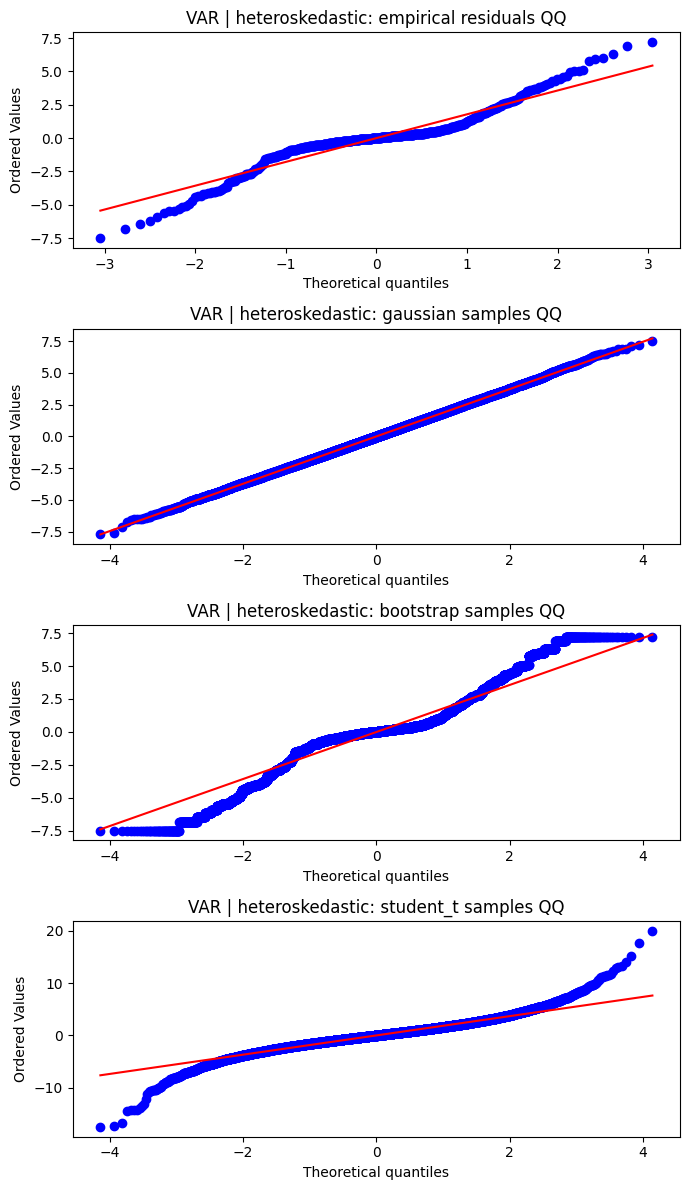

In [7]:
from src.plots.innovations import plot_innovation_qq_comparison

plot_innovation_qq_comparison(
    residual_store=residual_store,
    sampled_innovations=sampled_innovations,
    innovation_model_names=innovation_model_names,
    forecast_model="VAR",
    dgp_name="heteroskedastic",
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_heteroskedastic_innovation_qq_comparison.png"
)

print(
    "Saved: var_heteroskedastic_innovation_qq_comparison.png"
)